In [ ]:
import numpy as np

def generate_synthetic_eeg_dataset(
    n_samples=5000,
    n_channels=4,
    length=512,
    n_classes=5,
    noise_std=0.1,
    seed=0):

    np.random.seed(seed)
    X = []
    y = []

    for label in range(n_classes):
        for _ in range(n_samples // n_classes):

            t = np.linspace(0, 1, length)
            freqs = [
                5 + label*2,
                12 + label,
                20 + label*0.5
            ]

            signal = np.zeros((n_channels, length))
            for ch in range(n_channels):

                sig = (
                    np.sin(2*np.pi*freqs[0]*t + np.random.rand()*2*np.pi) +
                    0.5*np.sin(2*np.pi*freqs[1]*t + np.random.rand()*2*np.pi) +
                    0.2*np.sin(2*np.pi*freqs[2]*t + np.random.rand()*2*np.pi)
                )

                sig += noise_std * np.random.randn(length)

                gain = np.random.uniform(0.8, 1.2)
                signal[ch] = sig * gain

            X.append(signal)
            y.append(label)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int64)

    print("Generated dataset:")
    print("X:", X.shape)
    print("y:", y.shape)

    return X, y

# Generate dataset
X, y = generate_synthetic_eeg_dataset(
    n_samples=5000,
    n_channels=4,
    length=512,
    n_classes=5,
    noise_std=0.12
)


Generated dataset:
X: (5000, 4, 512)
y: (5000,)


In [ ]:
samples = []

for i in range(len(X)):
    samples.append({
        "signal": X[i],      # (C, T)
        "label": int(y[i]),  # class (0–4)
        "device": "SYNTH"
    })

print("Total samples:", len(samples))


Total samples: 5000


In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from tqdm.auto import tqdm
import pickle, os

WINDOW = 32
HOP    = 16
PCA_DIM = 16
N_TOKENS = 128

def extract_subwindows(signal, window=WINDOW, hop=HOP):
    C, T = signal.shape
    out = []
    for st in range(0, T-window+1, hop):
        w = signal[:, st:st+window]
        out.append(w.reshape(-1))
    return np.stack(out)

# Collect windows
all_windows = []
for s in tqdm(samples):
    sw = extract_subwindows(s["signal"])
    idxs = np.random.choice(len(sw), size=min(3, len(sw)), replace=False)
    for i in idxs:
        all_windows.append(sw[i])

all_windows = np.array(all_windows)
print("Collected windows:", all_windows.shape)

# PCA
pca = PCA(n_components=PCA_DIM, whiten=True)
pca.fit(all_windows)
proj = pca.transform(all_windows)

# KMeans
kmeans = MiniBatchKMeans(n_clusters=N_TOKENS, batch_size=512)
kmeans.fit(proj)

print("Tokenizer ready.")


  0%|          | 0/5000 [00:00<?, ?it/s]

Collected windows: (15000, 128)
Tokenizer ready.


In [ ]:
X_tokens = []
y_labels = []

for s in tqdm(samples):
    sw = extract_subwindows(s["signal"])
    proj = pca.transform(sw)
    tok = kmeans.predict(proj)
    tok = tok[:64]  # optional cap
    X_tokens.append(tok)
    y_labels.append(s["label"])

print("Example token length:", len(X_tokens[0]))


  0%|          | 0/5000 [00:00<?, ?it/s]

Example token length: 31


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

class TokenDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def collate_fn(batch):
    seqs, labs = zip(*batch)
    max_len = max(len(s) for s in seqs)
    B = len(seqs)
    arr = torch.zeros((B, max_len), dtype=torch.long)
    mask = torch.zeros((B, max_len), dtype=torch.bool)
    for i, seq in enumerate(seqs):
        L = len(seq)
        arr[i, :L] = torch.tensor(seq, dtype=torch.long)
        mask[i, :L] = 1
    return arr, mask, torch.tensor(labs)

# Split 80/20
N = len(X_tokens)
idx = np.arange(N)
np.random.shuffle(idx)
split = int(0.8*N)

train_idx, test_idx = idx[:split], idx[split:]

train_ds = TokenDataset([X_tokens[i] for i in train_idx],
                        [y_labels[i] for i in train_idx])
test_ds  = TokenDataset([X_tokens[i] for i in test_idx],
                        [y_labels[i] for i in test_idx])

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=128, shuffle=False, collate_fn=collate_fn)


In [ ]:
import torch.nn as nn

VOCAB = N_TOKENS
CLASSES = len(np.unique(y_labels))

class PosEnc(nn.Module):
    def __init__(self, dim, max_len=128):
        super().__init__()
        self.pe = nn.Parameter(torch.randn(1, max_len, dim))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class TransformerEEG(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(VOCAB, 128)
        self.pos = PosEnc(128)

        enc_layer = nn.TransformerEncoderLayer(d_model=128, nhead=4)
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=4)

        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, CLASSES)
        )

    def forward(self, tokens, mask):
        x = self.emb(tokens)
        x = self.pos(x)
        x = x.permute(1,0,2)
        key_mask = ~mask
        out = self.enc(x, src_key_padding_mask=key_mask)
        out = out.permute(1,0,2).mean(dim=1)
        logits = self.fc(out)
        return logits

model = TransformerEEG().to(DEVICE)
print(model)


TransformerEEG(
  (emb): Embedding(128, 128)
  (pos): PosEnc()
  (enc): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=2048, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=2048, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=5, bias=True)
  )
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optim = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 12

for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0
    for tokens, mask, labs in train_loader:
        tokens = tokens.to(DEVICE)
        mask   = mask.to(DEVICE)
        labs   = labs.to(DEVICE)

        optim.zero_grad()
        logits = model(tokens, mask)
        loss = criterion(logits, labs)
        loss.backward()
        optim.step()
        total_loss += loss.item()

    # evaluate
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for tokens, mask, labs in test_loader:
            tokens = tokens.to(DEVICE)
            mask   = mask.to(DEVICE)
            labs   = labs.to(DEVICE)
            logits = model(tokens, mask)
            pred = logits.argmax(dim=1)
            correct += (pred == labs).sum().item()
            total += labs.size(0)

    acc = correct / total
    print(f"Epoch {epoch}: loss={total_loss:.2f}, test_acc={acc:.4f}")


Epoch 1: loss=43.31, test_acc=0.7220
Epoch 2: loss=25.42, test_acc=0.8570
Epoch 3: loss=16.62, test_acc=0.8790
Epoch 4: loss=11.95, test_acc=0.9050
Epoch 5: loss=9.18, test_acc=0.9280
Epoch 6: loss=8.07, test_acc=0.9120
Epoch 7: loss=6.20, test_acc=0.9220
Epoch 8: loss=5.51, test_acc=0.9330
Epoch 9: loss=4.71, test_acc=0.9420
Epoch 10: loss=4.10, test_acc=0.9360
Epoch 11: loss=3.50, test_acc=0.9370
Epoch 12: loss=3.40, test_acc=0.9460


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.9/56.9 kB 5.9 MB/s eta 0:00:00


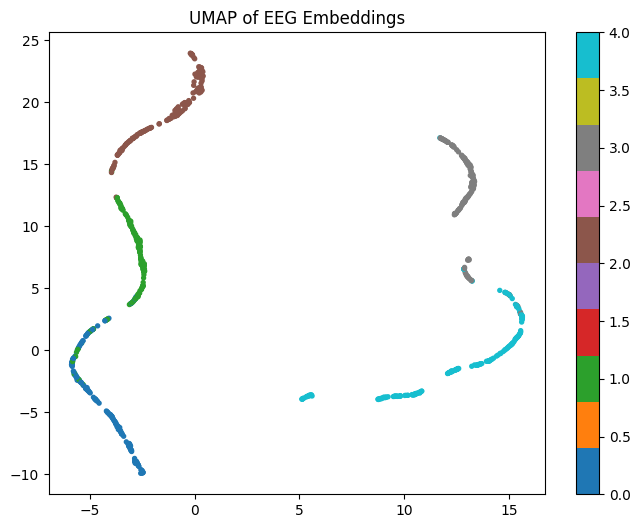

In [ ]:
!pip install umap-learn

import umap
import matplotlib.pyplot as plt

# Collect embeddings
model.eval()
all_emb = []
all_lbl = []

with torch.no_grad():
    for tokens, mask, labs in test_loader:
        tokens = tokens.to(DEVICE)
        mask   = mask.to(DEVICE)

        x = model.emb(tokens)
        x = model.pos(x)
        x = x.permute(1,0,2)
        x = model.enc(x)
        x = x.permute(1,0,2).mean(dim=1)

        all_emb.append(x.cpu().numpy())
        all_lbl.append(labs.numpy())

all_emb = np.vstack(all_emb)
all_lbl = np.hstack(all_lbl)

# UMAP
um = umap.UMAP(n_neighbors=20, min_dist=0.1, metric="cosine")
proj = um.fit_transform(all_emb)

plt.figure(figsize=(8,6))
plt.scatter(proj[:,0], proj[:,1], c=all_lbl, cmap="tab10", s=8)
plt.title("UMAP of EEG Embeddings")
plt.colorbar()
plt.show()


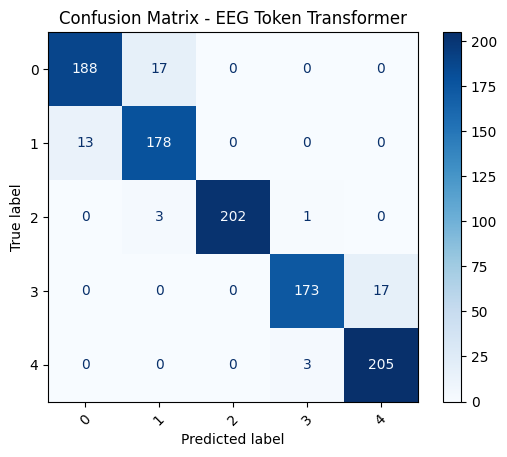

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for tokens, mask, labs in test_loader:
        tokens = tokens.to(DEVICE)
        mask   = mask.to(DEVICE)
        logits = model(tokens, mask)
        preds = logits.argmax(1).cpu().numpy()

        y_true.extend(labs.numpy())
        y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - EEG Token Transformer")
plt.show()


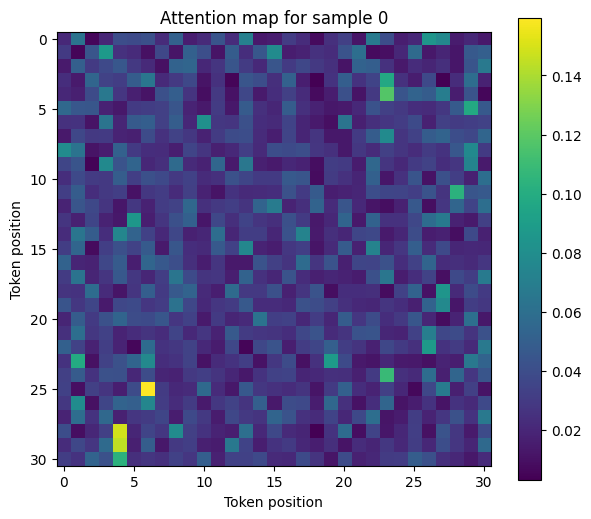

In [ ]:
def visualize_attention(sample_index=0):
    model.eval()

    tokens, mask, labs = next(iter(test_loader))
    tokens = tokens.to(DEVICE)
    mask = mask.to(DEVICE)

    # Only take 1 sequence
    seq = tokens[sample_index:sample_index+1]
    msk = mask[sample_index:sample_index+1]

    # Extract attention from first layer
    att_layer = model.enc.layers[0].self_attn

    with torch.no_grad():
        emb = model.emb(seq)
        emb = model.pos(emb)
        x = emb.permute(1,0,2)

        attn_out, attn_weights = att_layer(
            x, x, x,
            key_padding_mask=~msk
        )

    att = attn_weights[0].cpu().numpy()  # head 0

    plt.figure(figsize=(7,6))
    plt.imshow(att, cmap="viridis")
    plt.colorbar()
    plt.title("Attention map for sample "+str(sample_index))
    plt.xlabel("Token position")
    plt.ylabel("Token position")
    plt.show()

visualize_attention(0)
